In [2]:
from huggingface_hub import login

login()


In [3]:
from datasets import load_dataset

ds = load_dataset(
    "FlyRank/internship-lanes",
    "decline_recovery"
)

print(ds)

default_lanes/decline_recovery.parquet: reconstructing file:   0%|          |  0.00B / 3.88MB            

default_lanes/decline_recovery.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/56253 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'keyword_char_count', 'keyword_token_count', 'public_url_hash_id', 'public_url_char_count', 'public_url_path_depth', 'content_title_hash_id', 'content_title_char_count', 'content_title_token_count', 'impressions_90d', 'clicks_90d', 'sum_position_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'client_has_gsc', 'client_has_ga4', 'content_type', 'content_created_at', 'content_age_days', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining'],
        num_rows: 56253
    })
})


In [4]:
import pandas as pd

df = ds["train"].to_pandas()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 56253
Columns: 43


In [5]:
print(df.columns.tolist())

['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'keyword_char_count', 'keyword_token_count', 'public_url_hash_id', 'public_url_char_count', 'public_url_path_depth', 'content_title_hash_id', 'content_title_char_count', 'content_title_token_count', 'impressions_90d', 'clicks_90d', 'sum_position_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'client_has_gsc', 'client_has_ga4', 'content_type', 'content_created_at', 'content_age_days', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining']


In [6]:
df.head()

,client_hash_id,content_hash_id,keyword_hash_id,keyword_char_count,keyword_token_count,public_url_hash_id,public_url_char_count,public_url_path_depth,content_title_hash_id,content_title_char_count,...,trend_direction,trend_pct,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining
0,client_2094c6eb080311d5,content_9c786aea8fb2f1c6,keyword_d879cf3e66407e25,47,7,url_57e0b96b5c053290,98,3,title_48769559fe2659be,48,...,down,-99.4,15,False,False,False,False,False,False,True
1,client_2094c6eb080311d5,content_ea9b68bdccddcd4a,keyword_4000d86bb749226b,36,7,url_2f9bddde85164ed7,87,3,title_9de9bcfe0a9b6af8,36,...,down,-98.2,45,False,False,True,False,False,False,True
2,client_2094c6eb080311d5,content_4610b9c0a99de467,keyword_1e5f049eb5b7dff9,42,7,url_65d19d39cf4859db,93,3,title_19ccc000e7a54aa8,43,...,down,-89.7,55,False,False,True,False,False,False,True
3,client_2094c6eb080311d5,content_d5ec72bd00a5165f,keyword_b93dd6aa011fdd91,32,7,url_eefa7f3e0a53e404,83,3,title_b44521f255eae17f,33,...,down,-99.6,20,False,False,False,False,False,False,True
4,client_2094c6eb080311d5,content_e460345ff721587a,keyword_c8212eedb93ad237,33,6,url_0812e375eec6575c,84,3,title_46fdae840eb1ee6b,34,...,down,-98.3,30,False,False,False,False,False,False,True


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
ai_traffic_pct_90d,14896
scroll_rate_90d,14849
sessions_90d,13598
pageviews_90d,13598
ai_sessions_90d,13598
needs_engagement_fix,13598
ai_opportunity,13598
scroll_events_90d,13598
keyword_hash_id,849
is_underperformer,79


In [8]:
print(df["is_declining"].value_counts())
print()
print(df["is_declining"].value_counts(normalize=True) * 100)

is_declining
True    56253
Name: count, dtype: int64

is_declining
True    100.0
Name: proportion, dtype: float64


In [9]:
df[[
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "sessions_last_30d",
    "sessions_prev_30d",
    "ctr_90d",
    "avg_position_90d",
    "scroll_rate_90d",
    "content_age_days"
]].describe()

,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,impressions_last_30d,impressions_prev_30d,clicks_last_30d,clicks_prev_30d,sessions_last_30d,sessions_prev_30d,ctr_90d,avg_position_90d,scroll_rate_90d,content_age_days
count,56253.000000,56253.000000,42655.000000,42655.000000,56253.000000,56253.000000,56253.000000,56253.000000,56253.000000,56253.000000,56253.000000,56253.000000,41404.000000,56253.000000
mean,5636.431995,15.301459,40.806049,61.368023,885.748227,2091.040976,3.085151,6.012533,8.556859,15.415871,0.248699,17.306595,11.341376,230.147388
std,14159.090407,59.129442,334.423682,550.575594,2765.307637,5659.108988,12.821744,25.085453,26.725286,281.385285,0.360940,13.424760,19.133605,132.783576
min,100.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,32.000000
25%,590.000000,0.000000,5.000000,6.000000,70.000000,222.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.400000,0.000000,117.000000
50%,1513.000000,2.000000,14.000000,17.000000,201.000000,536.000000,0.000000,1.000000,2.000000,3.000000,0.140000,12.300000,3.160000,193.000000
75%,4723.000000,10.000000,38.000000,49.000000,663.000000,1661.000000,2.000000,4.000000,8.000000,13.000000,0.340000,23.900000,13.640000,326.000000
max,568800.000000,5165.000000,66067.000000,108311.000000,107248.000000,239803.000000,961.000000,2497.000000,2822.000000,65964.000000,9.020000,111.100000,300.000000,577.000000


In [10]:
print(df["trend_direction"].value_counts(dropna=False))

trend_direction
down    56253
Name: count, dtype: int64


In [11]:
print(df["trend_pct"].describe())

count    56253.000000
mean       -60.237893
std         19.282261
min       -100.000000
25%        -74.300000
50%        -57.800000
75%        -44.200000
max        -30.000000
Name: trend_pct, dtype: float64


In [12]:
df[[
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "sessions_last_30d",
    "sessions_prev_30d"
]].head(10)

,impressions_last_30d,impressions_prev_30d,clicks_last_30d,clicks_prev_30d,sessions_last_30d,sessions_prev_30d
0,1,166,0,0,1,8
1,12,666,0,0,0,5
2,42,409,0,3,3,7
3,1,224,0,0,1,5
4,4,234,0,0,1,1
5,24,309,0,0,8,8
6,55,281,1,1,6,5
7,55,136,0,1,1,3
8,18,149,0,0,3,6
9,100,500,0,0,2,5


In [13]:
import numpy as np

df_analysis = df.copy()

# Avoid division by zero
df_analysis["impression_change_pct"] = np.where(
    df_analysis["impressions_prev_30d"] > 0,
    ((df_analysis["impressions_last_30d"] -
      df_analysis["impressions_prev_30d"]) /
     df_analysis["impressions_prev_30d"]) * 100,
    np.nan
)

df_analysis["click_change_pct"] = np.where(
    df_analysis["clicks_prev_30d"] > 0,
    ((df_analysis["clicks_last_30d"] -
      df_analysis["clicks_prev_30d"]) /
     df_analysis["clicks_prev_30d"]) * 100,
    np.nan
)

df_analysis["session_change_pct"] = np.where(
    df_analysis["sessions_prev_30d"] > 0,
    ((df_analysis["sessions_last_30d"] -
      df_analysis["sessions_prev_30d"]) /
     df_analysis["sessions_prev_30d"]) * 100,
    np.nan
)

df_analysis[
    [
        "impression_change_pct",
        "click_change_pct",
        "session_change_pct"
    ]
].describe()

,impression_change_pct,click_change_pct,session_change_pct
count,56253.000000,32097.000000,38256.000000
mean,-60.237733,-36.992758,-23.803014
std,19.282104,84.061164,160.290047
min,-100.000000,-100.000000,-100.000000
25%,-74.315789,-100.000000,-71.428571
50%,-57.848837,-56.097561,-46.153846
75%,-44.179389,0.000000,0.000000
max,-30.003218,1100.000000,24980.000000


In [14]:
import numpy as np
import pandas as pd

score_df = df_analysis.copy()

# 1. Decline severity: 0 = no decline, 100 = complete decline
score_df["decline_severity"] = (
    -score_df["impression_change_pct"]
).clip(0, 100)

# 2. Historical visibility
# Log transformation reduces the effect of extremely large pages
score_df["log_prev_impressions"] = np.log1p(
    score_df["impressions_prev_30d"]
)

score_df["visibility_score"] = (
    score_df["log_prev_impressions"].rank(pct=True) * 100
)

# 3. Engagement decline
# Only calculate where previous clicks exist
score_df["engagement_decline"] = (
    -score_df["click_change_pct"]
).clip(0, 100)

# Missing engagement decline gets a neutral value
score_df["engagement_decline"] = (
    score_df["engagement_decline"].fillna(0)
)

# 4. Final Refresh Opportunity Score
score_df["refresh_opportunity_score"] = (
    0.50 * score_df["decline_severity"] +
    0.30 * score_df["visibility_score"] +
    0.20 * score_df["engagement_decline"]
)

# Keep score between 0 and 100
score_df["refresh_opportunity_score"] = (
    score_df["refresh_opportunity_score"].clip(0, 100)
)

print(
    score_df["refresh_opportunity_score"].describe()
)

count    56253.000000
mean        51.263013
std         15.533127
min         15.682575
25%         40.429874
50%         50.346662
75%         60.644438
max         99.251637
Name: refresh_opportunity_score, dtype: float64


In [15]:
score_df[
    [
        "content_hash_id",
        "impressions_prev_30d",
        "impressions_last_30d",
        "clicks_prev_30d",
        "clicks_last_30d",
        "decline_severity",
        "visibility_score",
        "engagement_decline",
        "refresh_opportunity_score"
    ]
].sort_values(
    "refresh_opportunity_score",
    ascending=False
).head(20)

,content_hash_id,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,decline_severity,visibility_score,engagement_decline,refresh_opportunity_score
16719,content_13ef916471e84dd8,14595,36,1,0,99.753340,97.916556,100.0,99.251637
14061,content_ef232b62b00d39b6,10656,6,40,0,99.943694,96.592182,100.0,98.949501
13841,content_8b80b3df6c034ccc,10363,1,40,0,99.990350,96.282865,100.0,98.880035
14314,content_4d4654ba395c8702,10353,2,40,0,99.980682,96.258866,100.0,98.868001
13835,content_78f45d38b6a4c659,10302,0,40,0,100.000000,96.091764,100.0,98.827529
13889,content_e6a626cec5d9dc6d,10345,10,40,0,99.903335,96.229534,100.0,98.820528
14261,content_4ea378a25b07e646,10331,8,40,0,99.922563,96.185092,100.0,98.816809
14181,content_e1ef962b401e21a0,10311,6,40,0,99.941810,96.118429,100.0,98.806434
13541,content_8409efd26bf89d40,10279,4,40,0,99.961086,96.013546,100.0,98.784607
13579,content_ddb2734b3b3a3b7f,10343,19,41,0,99.816301,96.221535,100.0,98.774611


In [17]:
# Create refresh opportunity score

df["impression_change_pct"] = (
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"].replace(0, 1)
) * 100

df["click_change_pct"] = (
    (df["clicks_last_30d"] - df["clicks_prev_30d"])
    / df["clicks_prev_30d"].replace(0, 1)
) * 100

df["session_change_pct"] = (
    (df["sessions_last_30d"] - df["sessions_prev_30d"])
    / df["sessions_prev_30d"].replace(0, 1)
) * 100

# Decline severity: more negative trend = higher severity
df["decline_severity"] = (-df["trend_pct"]).clip(0, 100)

# Visibility score based on impression decline
df["visibility_score"] = (-df["impression_change_pct"]).clip(0, 100)

# Engagement decline
df["engagement_decline"] = (-df["click_change_pct"]).clip(0, 100)

# Final opportunity score
df["refresh_opportunity_score"] = (
    0.4 * df["decline_severity"] +
    0.35 * df["visibility_score"] +
    0.25 * df["engagement_decline"]
)

df["refresh_opportunity_score"] = (
    df["refresh_opportunity_score"].clip(0, 100)
)

df[["content_hash_id", "decline_severity",
    "visibility_score", "engagement_decline",
    "refresh_opportunity_score"]].head(10)

,content_hash_id,decline_severity,visibility_score,engagement_decline,refresh_opportunity_score
0,content_9c786aea8fb2f1c6,99.4,99.397590,-0.0,74.549157
1,content_ea9b68bdccddcd4a,98.2,98.198198,-0.0,73.649369
2,content_4610b9c0a99de467,89.7,89.731051,100.0,92.285868
3,content_d5ec72bd00a5165f,99.6,99.553571,-0.0,74.683750
4,content_e460345ff721587a,98.3,98.290598,-0.0,73.721709
5,content_4898e600b21d59cd,92.2,92.233010,-0.0,69.161553
6,content_2667cf97ccb6fad6,80.4,80.427046,-0.0,60.309466
7,content_2275ebffd36c4076,59.6,59.558824,100.0,69.685588
8,content_d6ac0fe37c48bcff,87.9,87.919463,-0.0,65.931812
9,content_b7600cccc91fdf49,80.0,80.000000,-0.0,60.000000


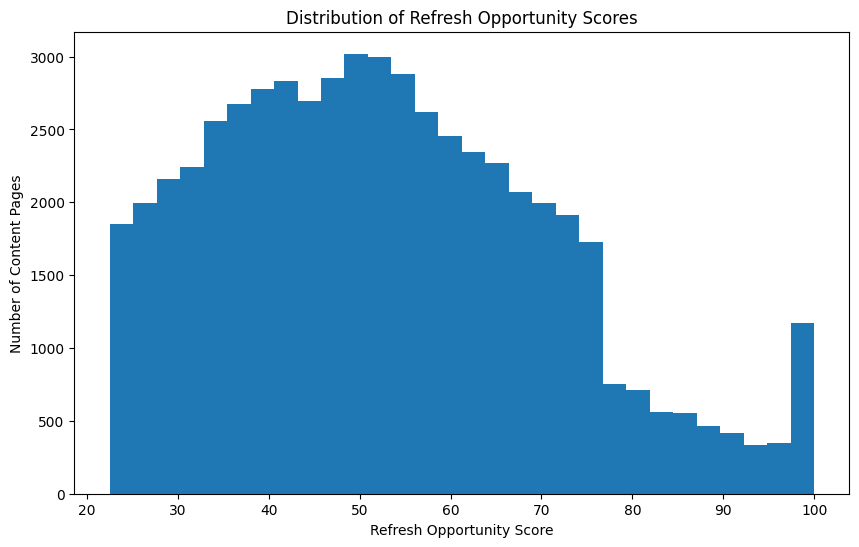

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["refresh_opportunity_score"], bins=30)
plt.xlabel("Refresh Opportunity Score")
plt.ylabel("Number of Content Pages")
plt.title("Distribution of Refresh Opportunity Scores")
plt.show()

In [19]:
top_20 = df.sort_values(
    "refresh_opportunity_score",
    ascending=False
)[[
    "content_hash_id",
    "impressions_prev_30d",
    "impressions_last_30d",
    "clicks_prev_30d",
    "clicks_last_30d",
    "decline_severity",
    "visibility_score",
    "engagement_decline",
    "refresh_opportunity_score"
]].head(20)

top_20

,content_hash_id,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,decline_severity,visibility_score,engagement_decline,refresh_opportunity_score
32687,content_9079564e7260bf87,187,0,1,0,100.0,100.0,100.0,100.0
32561,content_1ba605c1e6e5e8a3,202,0,1,0,100.0,100.0,100.0,100.0
32558,content_432b86862e32882d,132,0,1,0,100.0,100.0,100.0,100.0
32552,content_50518a10a0ec5a81,120,0,2,0,100.0,100.0,100.0,100.0
32549,content_bc4d729fcdf5b5f7,214,0,1,0,100.0,100.0,100.0,100.0
32546,content_dc761287f1a68030,113,0,2,0,100.0,100.0,100.0,100.0
32534,content_5a18e70b721936c0,669,0,1,0,100.0,100.0,100.0,100.0
32530,content_9246de05b3e21884,127,0,1,0,100.0,100.0,100.0,100.0
32529,content_70ae4e69c849d96d,137,0,3,0,100.0,100.0,100.0,100.0
32525,content_7f617953e99849c3,105,0,2,0,100.0,100.0,100.0,100.0


In [20]:
def classify_opportunity(score):
    if score >= 80:
        return "High"
    elif score >= 60:
        return "Medium"
    else:
        return "Low"

df["opportunity_level"] = df["refresh_opportunity_score"].apply(
    classify_opportunity
)

df["opportunity_level"].value_counts()

,count
opportunity_level,
Low,37458
Medium,14433
High,4362


In [21]:
df.groupby("opportunity_level")[
    "refresh_opportunity_score"
].agg(["count", "mean", "min", "max"])

,count,mean,min,max
opportunity_level,,,,
High,4362,90.685184,80.025365,100.000000
Low,37458,42.423412,22.501126,59.997556
Medium,14433,68.507457,60.000000,79.990382


In [22]:
high_priority = df[df["opportunity_level"] == "High"]

high_priority[
    [
        "impressions_prev_30d",
        "impressions_last_30d",
        "clicks_prev_30d",
        "clicks_last_30d",
        "decline_severity",
        "visibility_score",
        "engagement_decline",
        "refresh_opportunity_score"
    ]
].describe()

,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,decline_severity,visibility_score,engagement_decline,refresh_opportunity_score
count,4362.000000,4362.000000,4362.000000,4362.000000,4362.000000,4362.000000,4362.000000,4362.000000
mean,3356.845484,219.392251,12.636635,0.441770,88.237231,88.236995,98.029374,90.685184
std,5955.494073,793.529780,34.729984,3.305014,8.776105,8.774807,6.608095,6.814403
min,100.000000,0.000000,1.000000,0.000000,73.400000,73.350433,42.857143,80.025365
25%,259.000000,17.000000,1.000000,0.000000,80.600000,80.576283,100.000000,84.554118
50%,686.000000,56.000000,2.000000,0.000000,87.800000,87.797535,100.000000,90.236725
75%,4733.250000,167.000000,11.000000,0.000000,97.500000,97.457448,100.000000,97.892922
max,173369.000000,29323.000000,1409.000000,144.000000,100.000000,100.000000,100.000000,100.000000


In [23]:
high_priority[
    [
        "content_hash_id",
        "impressions_prev_30d",
        "impressions_last_30d",
        "clicks_prev_30d",
        "clicks_last_30d",
        "trend_pct",
        "refresh_opportunity_score"
    ]
].sort_values(
    "refresh_opportunity_score",
    ascending=False
).head(20)

,content_hash_id,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,trend_pct,refresh_opportunity_score
51789,content_7874b17afae775fc,120,0,1,0,-100.0,100.0
12580,content_1b8b97b8508240b0,116,0,1,0,-100.0,100.0
12602,content_7f252f6ab1626367,258,0,1,0,-100.0,100.0
48487,content_3c024ae9d97e726b,200,0,2,0,-100.0,100.0
12645,content_6857657da448869d,128,0,1,0,-100.0,100.0
13135,content_cfddb21db1c44431,149,0,1,0,-100.0,100.0
48441,content_f8221ed4b63c47d3,518,0,7,0,-100.0,100.0
13454,content_6a698428694673fc,10248,0,40,0,-100.0,100.0
13455,content_cbc7ab1970cb7298,10233,0,40,0,-100.0,100.0
46051,content_f10f0c23c56cc681,148,0,1,0,-100.0,100.0


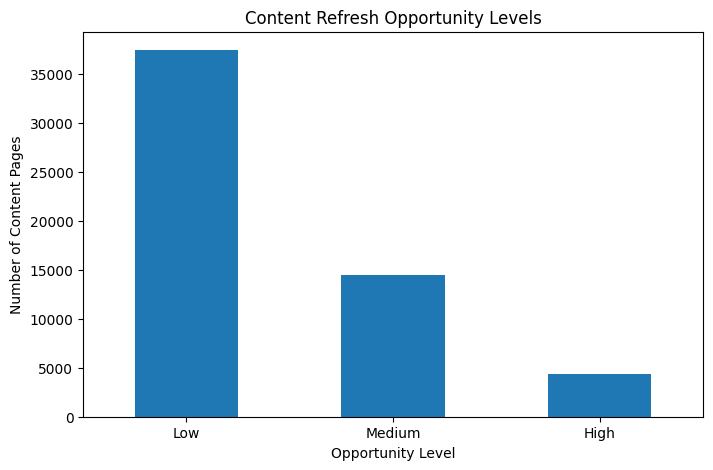

In [24]:
import matplotlib.pyplot as plt

# Opportunity level distribution
opportunity_counts = df["opportunity_level"].value_counts()

plt.figure(figsize=(8, 5))
opportunity_counts.plot(kind="bar")
plt.title("Content Refresh Opportunity Levels")
plt.xlabel("Opportunity Level")
plt.ylabel("Number of Content Pages")
plt.xticks(rotation=0)
plt.show()

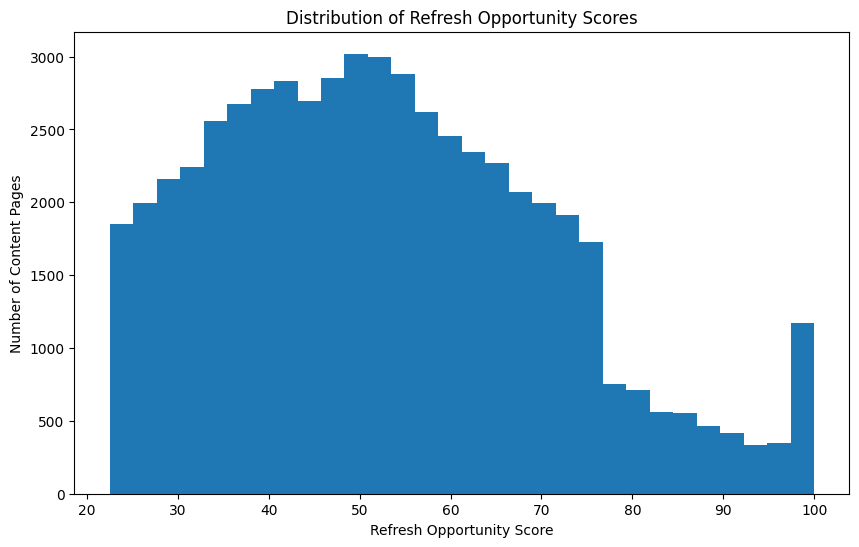

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(df["refresh_opportunity_score"], bins=30)

plt.title("Distribution of Refresh Opportunity Scores")
plt.xlabel("Refresh Opportunity Score")
plt.ylabel("Number of Content Pages")

plt.show()

In [26]:
top_20

,content_hash_id,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,decline_severity,visibility_score,engagement_decline,refresh_opportunity_score
32687,content_9079564e7260bf87,187,0,1,0,100.0,100.0,100.0,100.0
32561,content_1ba605c1e6e5e8a3,202,0,1,0,100.0,100.0,100.0,100.0
32558,content_432b86862e32882d,132,0,1,0,100.0,100.0,100.0,100.0
32552,content_50518a10a0ec5a81,120,0,2,0,100.0,100.0,100.0,100.0
32549,content_bc4d729fcdf5b5f7,214,0,1,0,100.0,100.0,100.0,100.0
32546,content_dc761287f1a68030,113,0,2,0,100.0,100.0,100.0,100.0
32534,content_5a18e70b721936c0,669,0,1,0,100.0,100.0,100.0,100.0
32530,content_9246de05b3e21884,127,0,1,0,100.0,100.0,100.0,100.0
32529,content_70ae4e69c849d96d,137,0,3,0,100.0,100.0,100.0,100.0
32525,content_7f617953e99849c3,105,0,2,0,100.0,100.0,100.0,100.0


In [27]:
# Analyze refresh opportunity levels

opportunity_summary = df.groupby("opportunity_level")[
    "refresh_opportunity_score"
].agg(["count", "mean", "min", "max"])

opportunity_summary

,count,mean,min,max
opportunity_level,,,,
High,4362,90.685184,80.025365,100.000000
Low,37458,42.423412,22.501126,59.997556
Medium,14433,68.507457,60.000000,79.990382


In [28]:
# Calculate percentage of content in each opportunity level

opportunity_percentage = (
    df["opportunity_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

opportunity_percentage

,proportion
opportunity_level,
Low,66.59
Medium,25.66
High,7.75


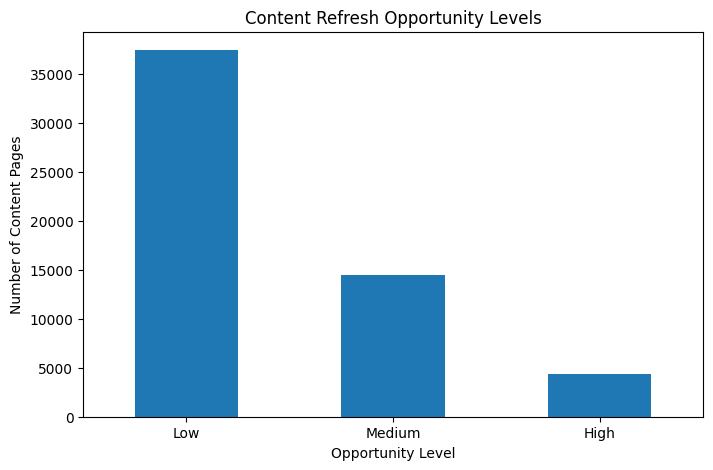

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df["opportunity_level"].value_counts().plot(kind="bar")

plt.title("Content Refresh Opportunity Levels")
plt.xlabel("Opportunity Level")
plt.ylabel("Number of Content Pages")
plt.xticks(rotation=0)

plt.show()

In [30]:
opportunity_summary = df.groupby("opportunity_level")[
    "refresh_opportunity_score"
].agg(["count", "mean", "min", "max"])

opportunity_summary

,count,mean,min,max
opportunity_level,,,,
High,4362,90.685184,80.025365,100.000000
Low,37458,42.423412,22.501126,59.997556
Medium,14433,68.507457,60.000000,79.990382


In [31]:
opportunity_percentage = (
    df["opportunity_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

opportunity_percentage

,proportion
opportunity_level,
Low,66.59
Medium,25.66
High,7.75


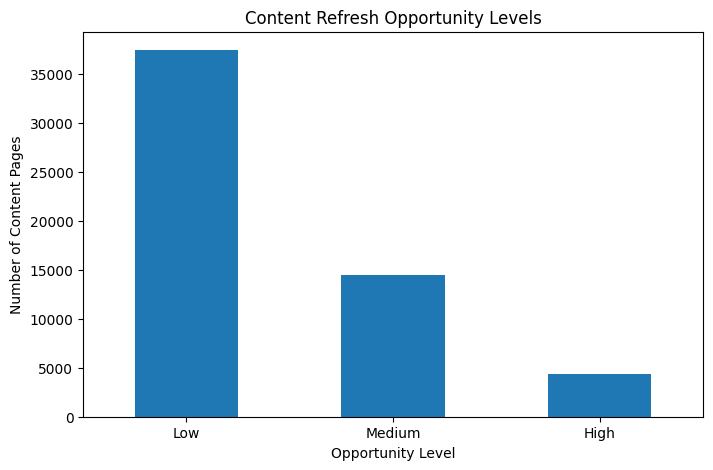

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df["opportunity_level"].value_counts().plot(kind="bar")

plt.title("Content Refresh Opportunity Levels")
plt.xlabel("Opportunity Level")
plt.ylabel("Number of Content Pages")
plt.xticks(rotation=0)

plt.show()

In [33]:
# Identify the highest-priority content pages

high_priority = df[
    df["opportunity_level"] == "High"
].sort_values(
    "refresh_opportunity_score",
    ascending=False
)

high_priority[
    [
        "content_hash_id",
        "impressions_prev_30d",
        "impressions_last_30d",
        "clicks_prev_30d",
        "clicks_last_30d",
        "trend_pct",
        "refresh_opportunity_score"
    ]
].head(20)

,content_hash_id,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,trend_pct,refresh_opportunity_score
51789,content_7874b17afae775fc,120,0,1,0,-100.0,100.0
12580,content_1b8b97b8508240b0,116,0,1,0,-100.0,100.0
12602,content_7f252f6ab1626367,258,0,1,0,-100.0,100.0
48487,content_3c024ae9d97e726b,200,0,2,0,-100.0,100.0
12645,content_6857657da448869d,128,0,1,0,-100.0,100.0
13135,content_cfddb21db1c44431,149,0,1,0,-100.0,100.0
48441,content_f8221ed4b63c47d3,518,0,7,0,-100.0,100.0
13454,content_6a698428694673fc,10248,0,40,0,-100.0,100.0
13455,content_cbc7ab1970cb7298,10233,0,40,0,-100.0,100.0
46051,content_f10f0c23c56cc681,148,0,1,0,-100.0,100.0


In [34]:
# High-priority content insights

high_priority_insights = high_priority[
    [
        "impressions_prev_30d",
        "impressions_last_30d",
        "clicks_prev_30d",
        "clicks_last_30d",
        "trend_pct",
        "refresh_opportunity_score"
    ]
].describe()

high_priority_insights

,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,trend_pct,refresh_opportunity_score
count,4362.000000,4362.000000,4362.000000,4362.000000,4362.000000,4362.000000
mean,3356.845484,219.392251,12.636635,0.441770,-88.237231,90.685184
std,5955.494073,793.529780,34.729984,3.305014,8.776105,6.814403
min,100.000000,0.000000,1.000000,0.000000,-100.000000,80.025365
25%,259.000000,17.000000,1.000000,0.000000,-97.500000,84.554118
50%,686.000000,56.000000,2.000000,0.000000,-87.800000,90.236725
75%,4733.250000,167.000000,11.000000,0.000000,-80.600000,97.892922
max,173369.000000,29323.000000,1409.000000,144.000000,-73.400000,100.000000


In [35]:
# Pages with complete impression loss

complete_loss = (
    (high_priority["impressions_last_30d"] == 0)
).sum()

print("High-priority pages:", len(high_priority))
print("Pages with zero recent impressions:", complete_loss)
print(
    "Percentage with zero recent impressions:",
    round(complete_loss / len(high_priority) * 100, 2),
    "%"
)

High-priority pages: 4362
Pages with zero recent impressions: 314
Percentage with zero recent impressions: 7.2 %


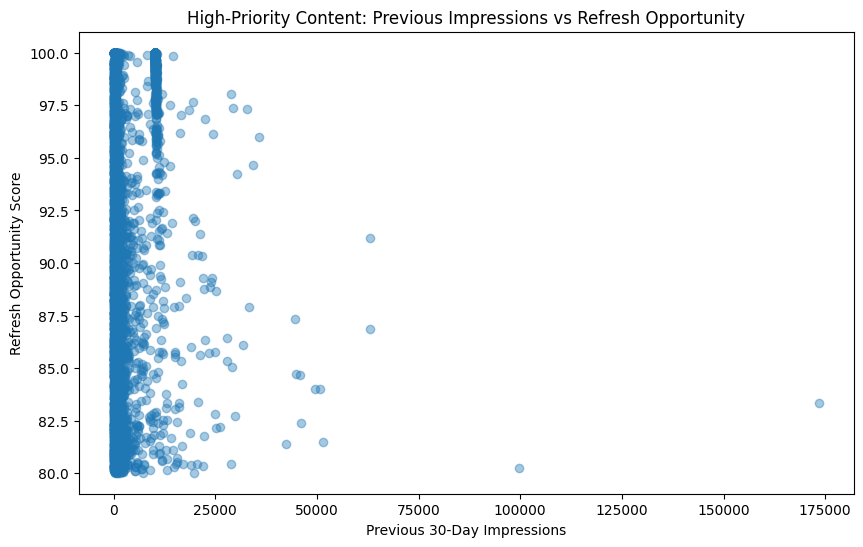

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    high_priority["impressions_prev_30d"],
    high_priority["refresh_opportunity_score"],
    alpha=0.4
)

plt.title("High-Priority Content: Previous Impressions vs Refresh Opportunity")
plt.xlabel("Previous 30-Day Impressions")
plt.ylabel("Refresh Opportunity Score")

plt.show()